# CASA0007 
## Practical 3: Hypothesis Testing</h1>
<div style="float:right"><img width="100" src="https://github.com/jreades/i2p/raw/master/img/casa_logo.jpg" /></div>

## Welcome!

In this practical, we will apply the hypothesis testing techniques to the schools dataset.

- Mean comparison test
- KS distribution test

In [1]:
# import relevant packages

import numpy as np
import scipy.stats as sps
import pandas as pd
import matplotlib.pyplot as plt

## Background 

Each schools trus tin the UK has to publish students performance. 
The variable 'PTL2BASICS_95_WGTAVG' represents the % of pupils at the end of KS4 achieving strong 9-5 passes in both English and mathematics GCSEs as a weighted average. 

In [2]:
base = "data/Performancetables_130242/2022-2023/"
na_vals = ["", "NA", "SUPP", "NP", "NE", "SP", "SN", "SUPPMAT"]
df_ks4 = pd.read_csv('https://raw.githubusercontent.com/huanfachen/QM/refs/heads/main/sessions/L2_data/england_ks4final.csv',
    na_values = na_vals
)

df_ks4.head()

/var/folders/4n/x6w1yfcx01qbymrsfpz4ybq00000gn/T/ipykernel_59919/358693895.py:3: DtypeWarning: Columns (75,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,144,145,146,147,148,149,150,151,152,177,178,179,180,181,182,183,186,187,188,189,190,191,192,194,195,196,198,199,200,202,203,204,206,207,208,210,211,212,214,215,216,218,219,220,222,223,224,230,233,234,235,236,237,238,239,242,243,244,245,246,247,248,251,252,253,254,255,256,257,266,267,268,269,270,271,272,281,282,283,284,285,286,287,296,297,298,299,300,301,302,311,312,313,314,315,316,317,335,336,337,340,341,342,345,346,347,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383,384,385,386,387,388,389,390,391,392,393,394,395,396,397,398,399,400,401,402,403,404,405,406,407,408,409,410) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ks4 = pd.read_csv('https://raw.githubusercontent.com/huanfachen/QM/refs/heads/main/sessions/L2_data/england_ks4final.csv',


,RECTYPE,LEA,ESTAB,URN,SCHNAME,SCHNAME_AC,ADDRESS1,ADDRESS2,ADDRESS3,TOWN,...,TAVENT_GFSM6CLA1A_PTQ_EE,TAVENT_GNFSM6CLA1A_PTQ_EE,TAVENT_GFSM6CLA1A_21_PTQ_EE,TAVENT_GNFSM6CLA1A_21_PTQ_EE,TAVENT_GFSM6CLA1A_22_PTQ_EE,TAVENT_GNFSM6CLA1A_22_PTQ_EE,TTOTENT_E_TOTAL_PTQ_EE,TTOTENT_E_COVID_IMPACTED_PTQ_EE,PTOTENT_E_COVID_IMPACTED_PTQ_EE,P8_BANDING
0,1,201.0,6007.0,100003.0,City of London School,NaN,107 Queen Victoria Street,NaN,NaN,London,...,NaN,NaN,NaN,NaN,NaN,NaN,569.0,3.0,1%,NaN
1,1,201.0,6005.0,100001.0,City of London School for Girls,NaN,St Giles' Terrace,Barbican,NaN,London,...,NaN,NaN,NaN,NaN,NaN,NaN,606.0,5.0,1%,NaN
2,1,201.0,6000.0,100544.0,David Game College,NaN,31 Jewry Street,London,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,53.0,1.0,2%,NaN
3,4,201.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,202.0,4285.0,100053.0,Acland Burghley School,NaN,Burghley Road,NaN,NaN,London,...,7.0,8.1,NaN,NaN,7.0,8.2,1397.0,0.0,0%,Average


In [3]:
info_cols = ['RECTYPE', 'LEA', 'SCHNAME', 'TOTPUPS', 'TOWN']
ebaccs_cols = ['EBACCAPS', 'EBACCAPS_GIRLS', 'EBACCAPS_BOYS']

df = df_ks4[info_cols + ebaccs_cols]

df = df.copy()

df.loc[:, ebaccs_cols] = df.loc[:, ebaccs_cols].apply(pd.to_numeric, errors='coerce')
df['TOTPUPS'] = pd.to_numeric(df['TOTPUPS'], errors='coerce').fillna(0).astype('int64')

df = df[df['RECTYPE'].isin([1, 2])]

df.head()

,RECTYPE,LEA,SCHNAME,TOTPUPS,TOWN,EBACCAPS,EBACCAPS_GIRLS,EBACCAPS_BOYS
0,1,201.0,City of London School,1045,London,2.10,NaN,2.10
1,1,201.0,City of London School for Girls,739,London,1.51,1.51,NaN
2,1,201.0,David Game College,365,NaN,0.56,0.46,0.60
4,1,202.0,Acland Burghley School,1163,London,4.62,4.05,4.82
5,1,202.0,The Camden School for Girls,1047,London,6.25,6.25,NaN


In [4]:
df_London = df[df['TOWN'] == 'London']
df_London = df_London[df_London['EBACCAPS'].notna()]

df_notLondon = df[df['TOWN'] != 'London']
df_notLondon = df_notLondon[df_notLondon['EBACCAPS'].notna()]

In [5]:
df_London['EBACCAPS'].describe()

count    385.000000
mean       3.788260
std        1.851894
min        0.000000
25%        3.020000
50%        4.290000
75%        4.970000
max        8.700000
Name: EBACCAPS, dtype: float64

In [6]:
df_notLondon['EBACCAPS'].describe()

count    4246.000000
mean        3.395921
std         1.659090
min         0.000000
25%         2.820000
50%         3.670000
75%         4.380000
max         8.560000
Name: EBACCAPS, dtype: float64

In [7]:
H_0 = 'Mean EBacc score in London = Mean EBacc score outside London'
H_1 = 'Mean EBacc score in London > Mean EBacc score outside London OR Mean EBacc score in London < Mean EBacc score outside London'

In [8]:
alpha = 0.05

In [9]:
London_std = df_London['EBACCAPS'].mean()
notLondon_std = df_notLondon['EBACCAPS'].mean()

In [10]:
London_std = df_London['EBACCAPS'].std()
notLondon_std = df_notLondon['EBACCAPS'].std()

# Calculate the ratio of standard deviations 
std_ratio = London_std/notLondon_std

print("std ratio =", std_ratio)

if std_ratio > 0.5 and std_ratio < 2:
    print("Can assume equal population standard deviations.")
    equal_stds = True
else:
    print("Cannot assume equal population standard deviations.")
    equal_stds = False

std ratio = 1.1162102116458004
Can assume equal population standard deviations.


In [11]:
test_stat, p_value = sps.ttest_ind(df_London['EBACCAPS'], df_notLondon['EBACCAPS'], equal_var = equal_stds)

print("test statistic = ", test_stat)
print("p-value =", p_value)

test statistic =  4.398340904538903
p-value = 1.1153058452679503e-05


In [12]:
if p_value < alpha:
    print(f"Reject the null hypothesis ({H_0}). Accept the alternative hypothesis ({H_1}).")
    print("Conclude that samples are drawn from populations with different means.")
elif p_value >= alpha:
    print(f"No significant evidence to reject the null hypothesis ({H_0}).")
    print("Assume samples are drawn from populations with the same mean.")

Reject the null hypothesis (Mean EBacc score in London = Mean EBacc score outside London). Accept the alternative hypothesis (Mean EBacc score in London > Mean EBacc score outside London OR Mean EBacc score in London < Mean EBacc score outside London).
Conclude that samples are drawn from populations with different means.


Now looking at the gender difference 

In [13]:
df[['EBACCAPS_GIRLS', 'EBACCAPS_BOYS']].describe()

,EBACCAPS_GIRLS,EBACCAPS_BOYS
count,3851.000000,3801.000000
mean,3.820223,3.492636
std,1.409632,1.395525
min,0.000000,0.000000
25%,3.290000,2.980000
50%,3.950000,3.630000
75%,4.610000,4.250000
max,8.700000,8.560000


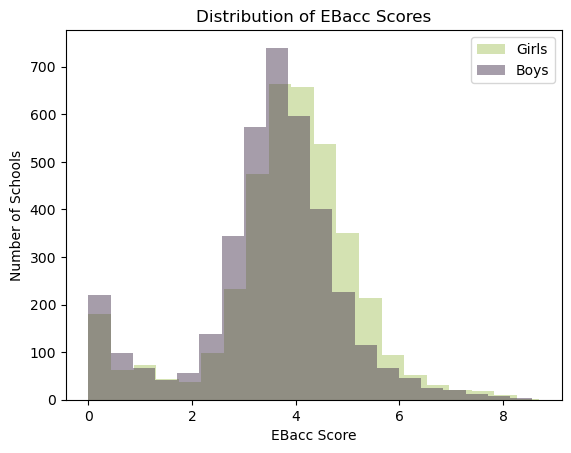

In [14]:
# Plot the histograms of EBacc scores - overlaying EBACCAPS_GIRLS and EBACCAPS_BOYS

plt.hist(df['EBACCAPS_GIRLS'], bins=20, color='#abc766', alpha=0.5, label='Girls')
plt.hist(df['EBACCAPS_BOYS'], bins=20, color='#4e3c56', alpha=0.5, label='Boys')
plt.xlabel('EBacc Score')
plt.ylabel('Number of Schools')
plt.title('Distribution of EBacc Scores')
plt.legend()
plt.show()

In [17]:
df[df['EBACCAPS_GIRLS'].notna()]['EBACCAPS_GIRLS']

1       1.51
2       0.46
4       4.05
5       6.25
6       0.00
        ... 
5801    4.39
5804    3.67
5805    4.93
5807    3.09
5808    0.39
Name: EBACCAPS_GIRLS, Length: 3851, dtype: float64

In [19]:
# use sps.ks_2samp to check if 'EBACCAPS_GIRLS' and 'EBACCAPS_BOYS' are drawn from the same distribution
ks_stat, ks_p_value = sps.ks_2samp(df[df['EBACCAPS_GIRLS'].notna()]['EBACCAPS_GIRLS'], df[df['EBACCAPS_BOYS'].notna()]['EBACCAPS_BOYS']) 
print("KS test statistic = ", ks_stat)
print("KS p-value =", ks_p_value)
if ks_p_value < alpha:
    print(f"Reject the null hypothesis that the samples are drawn from the same distribution.")
    print("Conclude that samples are drawn from populations with different distributions.")
else: 
    print(f"Fail to reject the null hypothesis that the samples are drawn from the same distribution.")
    print("Assume that samples are drawn from populations with the same distribution.")

KS test statistic =  0.14379151408924834
KS p-value = 5.931389311696697e-35
Reject the null hypothesis that the samples are drawn from the same distribution.
Conclude that samples are drawn from populations with different distributions.


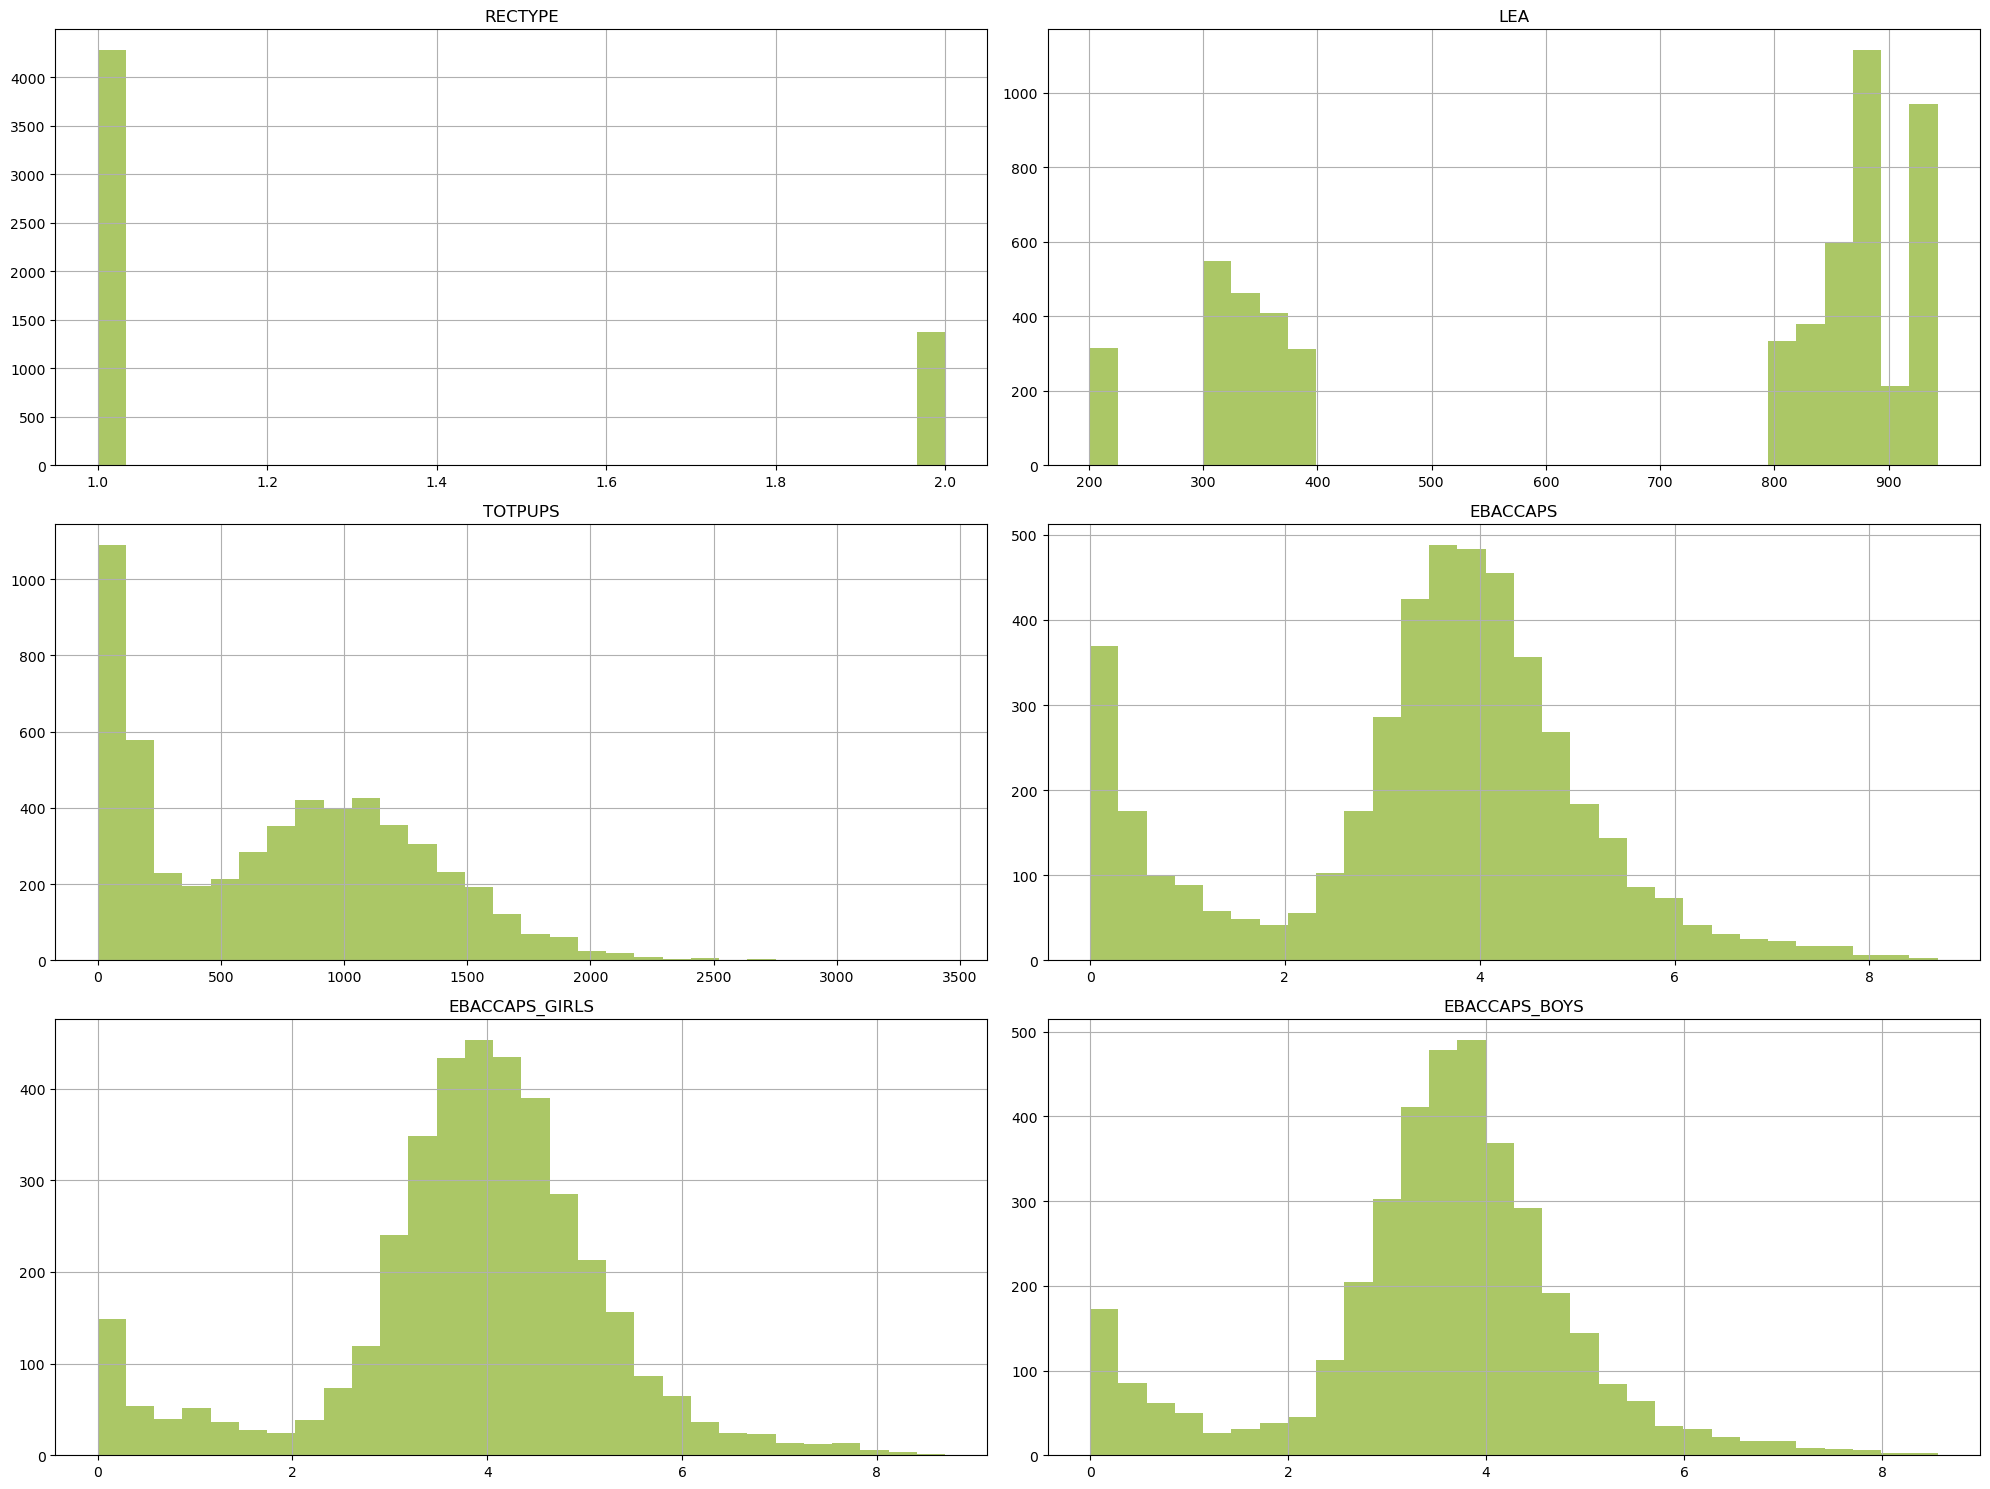

In [18]:

df.hist(bins=30, color='#abc766', figsize=(20, 15))
plt.tight_layout()
plt.show()

## Credits
### Contributors:
The following individuals have contributed to these teaching materials: [Bea Taylor](https://github.com/Bea-Taylor)

### License
These teaching materials are licensed under a mix of The MIT License and the Creative Commons Attribution-NonCommercial-ShareAlike 4.0 license.

### Acknowledgements
This tutorial is based on teaching resources developed by: [Huanfa Chen](huanfa.chen@ucl.ac.uk), Thomas Evans, Hannah Fry. 

### Dependencies
This notebook depends on the following libraries: pandas, matplotlib, numpy, scipy